# Classificação de posição de jogador com MLP

**Disciplina**: Machine Learning e Deep Learning

**Integrantes**: Gabriel Costa de Miranda, João Pedro Silva da Silva e Yago Patrick Schnorr Pinto

**Declaração de uso de IA**:
- Ferramenta utilizada: Claude (Anthropic)
- Finalidade do uso: Auxílio na geração de algumas partes do código (principalmente gráficos e funções maiores), geração de alguns markdowns e na retirada de dúvidas.
- Extensão aproximada da contribuição: cerca de 40% do notebook.
- Medidas adotadas para validação do conteúdo: Foi utilizado principalmente a validação de como estava sendo feito no notebook de exemplo e pesquisa na internet acerca de métodos ou trechos de código que não conhecemos.

## Imports

In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import random
import gc
import json

import tensorflow as tf
from tensorflow import keras
import optuna

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import f1_score, accuracy_score

In [53]:
SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED); np.random.seed(SEED)
keras.utils.set_random_seed(SEED)

## Carregamento dos dados

In [54]:
df = pd.read_csv('../../data/processed/player-stats-model.csv')
df = df.drop(columns=['Pos'])

## Features (X) e target (y)

In [55]:
X = df.drop(columns=['GK', 'DF', 'MF', 'MFFW', 'FW'])
y = df[['GK', 'DF', 'MF', 'MFFW', 'FW']]

print("X:", X.shape)
print("y:", y.shape)

X: (606, 9)
y: (606, 5)


## Split treino/teste (80/20, estratificado)

In [56]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=SEED)

## Validação cruzada (StratifiedKFold, 5 folds)

In [57]:
N_SPLITS        = 5     
MAX_EPOCHS      = 100   
INNER_VAL_SIZE  = 0.15  
N_TRIALS        = 25    

cv = StratifiedKFold(
    n_splits=N_SPLITS,
    shuffle=True,
    random_state=SEED
)

## One-hot → rótulo de classe

In [58]:
classes = y.columns.tolist()

NUM_CLASSES = len(classes)

y_train_labels = y_train.idxmax(axis=1)
y_test_labels = y_test.idxmax(axis=1)

## Arquitetura da MLP

In [59]:
def rede_mlp(n_features, n_classes):
    model = keras.Sequential([
        keras.layers.Input(shape=(n_features,)),
        keras.layers.Dense(32, activation='tanh'),
        keras.layers.Dense(16, activation='tanh'),
        keras.layers.Dense(n_classes, activation='softmax'),
    ])
    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy'],
    )
    return model

## Treino e avaliação por validação cruzada

In [60]:
fold_f1_scores = []
fold_epocas = []

for fold, (train_idx, val_idx) in enumerate(cv.split(X_train, y_train_labels), start=1):
    X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
    y_tr_labels = y_train_labels.iloc[train_idx]
    y_val_labels = y_train_labels.iloc[val_idx]

    X_fit, X_es, y_fit, y_es = train_test_split(
        X_tr, y_tr,
        test_size=INNER_VAL_SIZE,
        stratify=y_tr_labels,
        random_state=SEED + fold
    )

    scaler = StandardScaler().fit(X_fit)
    X_fit_scaled = scaler.transform(X_fit)
    X_es_scaled = scaler.transform(X_es)
    X_val_scaled = scaler.transform(X_val)

    model = rede_mlp(n_features=X_train.shape[1], n_classes=NUM_CLASSES)

    early_stopping = keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True
    )

    history = model.fit(
        X_fit_scaled, y_fit.values,
        validation_data=(X_es_scaled, y_es.values),
        epochs=MAX_EPOCHS,
        batch_size=32,
        callbacks=[early_stopping],
        verbose=0
    )

    y_pred = model.predict(X_val_scaled, verbose=0)
    y_pred_labels = np.array(classes)[np.argmax(y_pred, axis=1)]

    fold_f1 = f1_score(y_val_labels, y_pred_labels, average='macro')
    fold_f1_scores.append(fold_f1)
    fold_epocas.append(len(history.history['loss']))
    print(f"Fold {fold}: F1-macro = {fold_f1:.4f} (treinou {fold_epocas[-1]} épocas)")

fold_f1_scores = np.array(fold_f1_scores)
print(f"\nF1-macro médio: {fold_f1_scores.mean():.4f} ± {fold_f1_scores.std():.4f}")
print(f"Épocas médias até parar: {np.mean(fold_epocas):.1f} de no máximo {MAX_EPOCHS}")

Fold 1: F1-macro = 0.6960 (treinou 50 épocas)
Fold 2: F1-macro = 0.6423 (treinou 100 épocas)
Fold 3: F1-macro = 0.6790 (treinou 88 épocas)
Fold 4: F1-macro = 0.7206 (treinou 100 épocas)
Fold 5: F1-macro = 0.6885 (treinou 83 épocas)

F1-macro médio: 0.6853 ± 0.0255
Épocas médias até parar: 84.2 de no máximo 100


## Busca de hiperparâmetros

### Espaço de busca

| Hiperparâmetro | Espaço | Motivo da faixa |
|---|---|---|
| `n_layers` | 1 a 3 | 9 features não pedem rede profunda |
| `n_units` | 16 a 128, passo 16 | dataset pequeno (606 linhas); redes muito largas tendem a decorar |
| `activation` | sigmoid, tanh, relu, elu, swish | as ativações vistas em aula |
| `learning_rate` | 1e-4 a 2e-2, escala log | cobre de aprendizado lento a agressivo |
| `batch_size` | 16, 32, 64 | com ~390 linhas por treino, lotes maiores dariam poucas atualizações por época |
| `optimizer` | adam, rmsprop, sgd | |
| `patience` | 3 a 8 | paciência do early stopping |

In [61]:
def criar_otimizador(nome, learning_rate):
    if nome == 'adam':
        return keras.optimizers.Adam(learning_rate=learning_rate)
    if nome == 'rmsprop':
        return keras.optimizers.RMSprop(learning_rate=learning_rate)
    if nome == 'sgd':
        return keras.optimizers.SGD(learning_rate=learning_rate)
    raise ValueError(f"Otimizador desconhecido: {nome}")


def rede_mlp_params(params):
    model = keras.Sequential([keras.layers.Input(shape=(X_train.shape[1],))])
    for _ in range(params['n_layers']):
        model.add(keras.layers.Dense(params['n_units'], activation=params['activation']))
    model.add(keras.layers.Dense(NUM_CLASSES, activation='softmax'))
    model.compile(
        optimizer=criar_otimizador(params['optimizer'], params['learning_rate']),
        loss='categorical_crossentropy',
        metrics=['accuracy'],
    )
    return model

### Função que será usada no RandomSearch/TPE

In [ ]:
def objective(trial):
    params = {
        'n_layers': trial.suggest_int('n_layers', 1, 3),
        'n_units': trial.suggest_int('n_units', 16, 128, step=16),
        'activation': trial.suggest_categorical('activation', ['sigmoid', 'tanh', 'relu', 'elu', 'swish']),
        'learning_rate': trial.suggest_float('learning_rate', 1e-4, 2e-2, log=True),
        'batch_size': trial.suggest_categorical('batch_size', [16, 32, 64]),
        'optimizer': trial.suggest_categorical('optimizer', ['adam', 'rmsprop', 'sgd']),
        'patience': trial.suggest_int('patience', 3, 8),
    }

    fold_f1_scores = []
    fold_acc_scores = []
    fold_epocas = []

    for fold, (train_idx, val_idx) in enumerate(cv.split(X_train, y_train_labels), start=1):
        X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
        y_tr_labels = y_train_labels.iloc[train_idx]
        y_val_labels = y_train_labels.iloc[val_idx]

        X_fit, X_es, y_fit, y_es = train_test_split(
            X_tr, y_tr,
            test_size=INNER_VAL_SIZE,
            stratify=y_tr_labels,
            random_state=SEED + fold
        )

        scaler = StandardScaler().fit(X_fit)
        X_fit_scaled = scaler.transform(X_fit)
        X_es_scaled = scaler.transform(X_es)
        X_val_scaled = scaler.transform(X_val)

        keras.backend.clear_session()
        keras.utils.set_random_seed(SEED + fold)

        model = rede_mlp_params(params)

        early_stopping = keras.callbacks.EarlyStopping(
            monitor='val_loss',
            patience=params['patience'],
            restore_best_weights=True
        )

        history = model.fit(
            X_fit_scaled, y_fit.values,
            validation_data=(X_es_scaled, y_es.values),
            epochs=MAX_EPOCHS,
            batch_size=params['batch_size'],
            callbacks=[early_stopping],
            verbose=0
        )

        y_pred = model.predict(X_val_scaled, verbose=0)
        y_pred_labels = np.array(classes)[np.argmax(y_pred, axis=1)]

        fold_f1_scores.append(f1_score(y_val_labels, y_pred_labels, average='macro'))
        fold_acc_scores.append(accuracy_score(y_val_labels, y_pred_labels))
        fold_epocas.append(len(history.history['loss']))

        del model
        keras.backend.clear_session()
        gc.collect()

    trial.set_user_attr('f1_std', float(np.std(fold_f1_scores)))
    trial.set_user_attr('accuracy_mean', float(np.mean(fold_acc_scores)))
    trial.set_user_attr('epocas_medias', float(np.mean(fold_epocas)))

    return float(np.mean(fold_f1_scores))

## Random Search (baseline)

In [63]:
optuna.logging.set_verbosity(optuna.logging.WARNING)

study_rs = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.RandomSampler(seed=SEED),
)

study_rs.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)

Best trial: 12. Best value: 0.68097: 100%|██████████| 25/25 [18:06<00:00, 43.46s/it]


### Melhor configuração e principais trials

In [64]:
print(f"Trials realizados: {len(study_rs.trials)}")
print(f"Melhor trial: {study_rs.best_trial.number}")
print(f"F1-macro médio (CV): {study_rs.best_value:.4f}")
print(f"Desvio-padrão do F1: {study_rs.best_trial.user_attrs['f1_std']:.4f}")
print(f"Accuracy média (CV): {study_rs.best_trial.user_attrs['accuracy_mean']:.4f}")

print("\nHiperparâmetros:")
for nome, valor in study_rs.best_params.items():
    print(f"  {nome}: {valor}")

Trials realizados: 25
Melhor trial: 12
F1-macro médio (CV): 0.6810
Desvio-padrão do F1: 0.0476
Accuracy média (CV): 0.7189

Hiperparâmetros:
  n_layers: 2
  n_units: 16
  activation: sigmoid
  learning_rate: 0.0018946706217082751
  batch_size: 16
  optimizer: rmsprop
  patience: 5


In [65]:
df_trials_rs = study_rs.trials_dataframe()
colunas_params = [c for c in df_trials_rs.columns if c.startswith('params_')]

df_rs = (
    df_trials_rs[['number', 'value', 'user_attrs_f1_std', 'user_attrs_accuracy_mean',
                  'user_attrs_epocas_medias', *colunas_params]]
    .rename(columns={
        'number': 'trial',
        'value': 'f1_macro_cv',
        'user_attrs_f1_std': 'f1_std',
        'user_attrs_accuracy_mean': 'accuracy_cv',
        'user_attrs_epocas_medias': 'epocas_medias',
    })
    .rename(columns=lambda c: c.replace('params_', ''))
    .sort_values('f1_macro_cv', ascending=False)
    .reset_index(drop=True)
)

os.makedirs('results', exist_ok=True)
df_rs.to_csv('results/random_search_trials.csv', index=False)

df_rs.head(10)

,trial,f1_macro_cv,f1_std,accuracy_cv,epocas_medias,activation,batch_size,learning_rate,n_layers,n_units,optimizer,patience
0,12,0.680970,0.047639,0.718943,95.4,sigmoid,16,0.001895,2,16,rmsprop,5
1,9,0.680169,0.039813,0.706658,34.4,relu,16,0.001394,1,80,adam,4
2,22,0.679688,0.033319,0.712736,12.6,swish,64,0.004160,2,112,adam,5
3,10,0.671189,0.040931,0.708698,10.0,relu,32,0.005656,3,32,rmsprop,3
4,17,0.670365,0.041109,0.704489,79.4,swish,32,0.000210,2,128,rmsprop,4
5,14,0.667943,0.029110,0.704467,6.8,relu,32,0.005220,2,96,adam,4
6,24,0.665013,0.045239,0.704446,87.0,swish,16,0.012113,2,96,sgd,3
7,0,0.663885,0.034802,0.698260,22.2,sigmoid,32,0.009842,2,128,adam,4
8,19,0.662677,0.031341,0.692096,18.2,relu,64,0.007813,1,64,adam,3
9,3,0.659075,0.030883,0.690185,12.8,elu,64,0.014515,2,48,rmsprop,4


## TPE 

In [66]:
N_STARTUP_TRIALS = 10

optuna.logging.set_verbosity(optuna.logging.WARNING)

sampler = optuna.samplers.TPESampler(seed=SEED, n_startup_trials=N_STARTUP_TRIALS)

study_tpe = optuna.create_study(
    direction='maximize',
    sampler=sampler,
)

study_tpe.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)

Best trial: 16. Best value: 0.686022: 100%|██████████| 25/25 [19:22<00:00, 46.51s/it]


### Melhor configuração e principais trials

In [67]:
print(f"Trials realizados: {len(study_tpe.trials)}")
print(f"Melhor trial: {study_tpe.best_trial.number}")
print(f"F1-macro médio (CV): {study_tpe.best_value:.4f}")
print(f"Desvio-padrão do F1: {study_tpe.best_trial.user_attrs['f1_std']:.4f}")
print(f"Accuracy média (CV): {study_tpe.best_trial.user_attrs['accuracy_mean']:.4f}")

print("\nHiperparâmetros:")
for nome, valor in study_tpe.best_params.items():
    print(f"  {nome}: {valor}")

os.makedirs('results', exist_ok=True)
with open('results/tpe_best_params.json', 'w') as f:
    json.dump(study_tpe.best_params, f, indent=2)

Trials realizados: 25
Melhor trial: 16
F1-macro médio (CV): 0.6860
Desvio-padrão do F1: 0.0384
Accuracy média (CV): 0.7169

Hiperparâmetros:
  n_layers: 2
  n_units: 112
  activation: swish
  learning_rate: 0.0013597884252475028
  batch_size: 64
  optimizer: adam
  patience: 4


In [68]:
df_trials_tpe = study_tpe.trials_dataframe()
colunas_params = [c for c in df_trials_tpe.columns if c.startswith('params_')]

df_tpe = (
    df_trials_tpe[['number', 'value', 'user_attrs_f1_std', 'user_attrs_accuracy_mean',
                   'user_attrs_epocas_medias', *colunas_params]]
    .rename(columns={
        'number': 'trial',
        'value': 'f1_macro_cv',
        'user_attrs_f1_std': 'f1_std',
        'user_attrs_accuracy_mean': 'accuracy_cv',
        'user_attrs_epocas_medias': 'epocas_medias',
    })
    .rename(columns=lambda c: c.replace('params_', ''))
    .sort_values('f1_macro_cv', ascending=False)
    .reset_index(drop=True)
)

df_tpe.to_csv('results/tpe_trials.csv', index=False)

df_tpe.head(10)

,trial,f1_macro_cv,f1_std,accuracy_cv,epocas_medias,activation,batch_size,learning_rate,n_layers,n_units,optimizer,patience
0,16,0.686022,0.038375,0.716881,25.6,swish,64,0.001360,2,112,adam,4
1,19,0.682476,0.042809,0.723088,56.0,relu,16,0.001152,1,48,adam,4
2,9,0.680169,0.039813,0.706658,34.4,relu,16,0.001394,1,80,adam,4
3,17,0.675352,0.055689,0.710610,41.0,swish,32,0.000512,2,112,adam,4
4,15,0.671486,0.020948,0.704489,12.0,swish,64,0.003308,2,128,adam,4
5,11,0.671185,0.032902,0.710674,7.0,swish,32,0.006096,2,112,adam,3
6,24,0.670575,0.026833,0.706594,89.8,swish,64,0.000695,1,112,adam,4
7,23,0.668014,0.022291,0.704467,93.0,swish,64,0.000269,2,80,adam,3
8,18,0.666926,0.029789,0.702470,45.0,relu,64,0.000553,2,128,adam,3
9,12,0.665070,0.042665,0.702405,19.6,swish,32,0.003610,1,96,adam,3


### Gráfico de evolução da busca

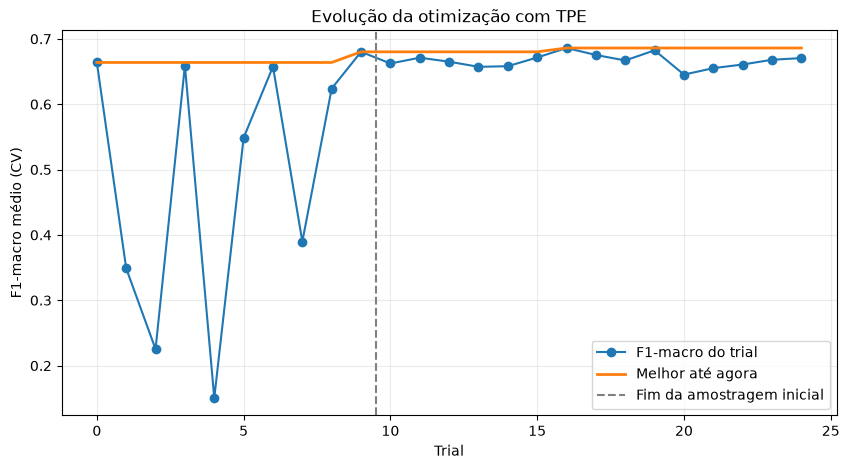

In [69]:
df_evolucao = df_tpe.sort_values('trial').reset_index(drop=True)
df_evolucao['melhor_ate_agora'] = df_evolucao['f1_macro_cv'].cummax()

plt.figure(figsize=(10, 5))
plt.plot(df_evolucao['trial'], df_evolucao['f1_macro_cv'], marker='o', label='F1-macro do trial')
plt.plot(df_evolucao['trial'], df_evolucao['melhor_ate_agora'], linewidth=2, label='Melhor até agora')
plt.axvline(N_STARTUP_TRIALS - 0.5, linestyle='--', color='gray', label='Fim da amostragem inicial')

plt.xlabel('Trial')
plt.ylabel('F1-macro médio (CV)')
plt.title('Evolução da otimização com TPE')
plt.legend()
plt.grid(alpha=0.25)
plt.show()

### Gráfico de importância estimada dos hiperparâmetros

,hiperparametro,importancia
0,optimizer,0.603130
1,activation,0.191605
2,n_units,0.092970
3,learning_rate,0.035376
4,n_layers,0.027262
5,batch_size,0.027225
6,patience,0.022432


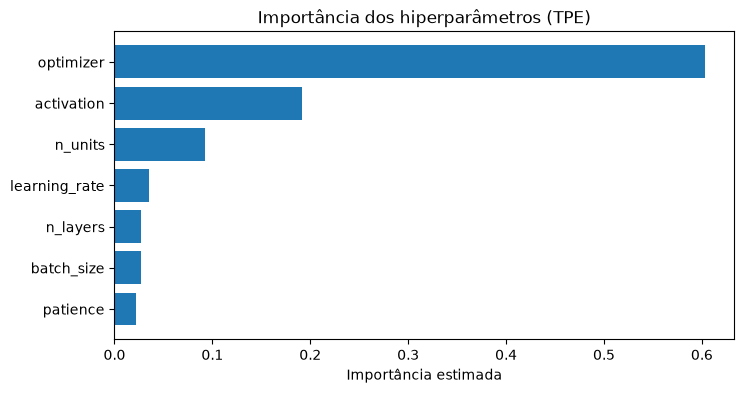

Hiperparâmetro com maior importância estimada: optimizer


: 

In [ ]:
evaluator = optuna.importance.FanovaImportanceEvaluator(seed=SEED)
importancias = optuna.importance.get_param_importances(study_tpe, evaluator=evaluator)

df_importancias = (
    pd.DataFrame({
        'hiperparametro': list(importancias.keys()),
        'importancia': list(importancias.values()),
    })
    .sort_values('importancia', ascending=False)
    .reset_index(drop=True)
)
df_importancias.to_csv('results/tpe_param_importances.csv', index=False)
display(df_importancias)

plt.figure(figsize=(8, 4))
plt.barh(df_importancias['hiperparametro'][::-1], df_importancias['importancia'][::-1])
plt.xlabel('Importância estimada')
plt.title('Importância dos hiperparâmetros (TPE)')
plt.show()

print("Hiperparâmetro com maior importância estimada:", df_importancias.loc[0, 'hiperparametro'])